# EARTHSC 5201: Introduction to Seismology

## Homework 1

**Seyhmus Tunc**  
The Ohio State University  
Autumn 2026  

## Question 1 – Source, Path, and Site Terms

Source, path, and site terms describe the main factors that control observed earthquake ground motions, as illustrated in Figure 1.

**Source terms** are related to the earthquake itself,
including magnitude, fault type, rupture direction, and depth. Larger earthquakes
generally produce stronger motions and longer shaking durations.

**Path terms** describe how seismic waves change as they travel from the source
to the site. Common examples include source-to-site distance, geometric spreading,
and attenuation. Ground motions generally decrease with distance as seismic waves
lose energy.

**Site terms** describe how local ground conditions change the incoming seismic
waves. Examples include soil stiffness, sediment thickness, basin effects, and
topography. For example, in my current research in Seattle, I observe higher
accelerations at sites within the sedimentary basin, while sites with stiffer
ground conditions generally show lower accelerations. This shows how local geology (i.e., site term)
can significantly change the recorded ground motion even for the same earthquake.

<p align="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS1IC6C3RhT5sYeeeN3m9QKg5VZKImRMenwvs4EV0HeJ8WQvqTIgt6RQwE&s=10"
       width="500">
</p>

<p align="center">
  <b>Figure 1.</b> Schematic representation of source, path, and site effects on observed ground motions (Schultz and Nanometrics, 2019).
</p>

## References

Schultz, R., & Nanometrics Inc. (2019). *Initial Seismic Hazard Assessment for
the Induced Earthquakes Near Fox Creek, Alberta (between January 2013 and
January 2016).* AER/AGS Special Report 104.

## Question 2 – Urban and Rural Seismic Noise

For this analysis, seismic stations in the San Francisco Bay Area are examined to select one urban and one rural station with vertical-component velocity measurements. One day of seismic data will be used to compare the noise characteristics of the two stations.

In [ ]:
# Installing required packages
!pip install obspy folium -q

In [165]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import folium

from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal import PPSD

In [166]:
client = Client("NCEDC")

In [167]:
# San Francisco coordinates
sf_lat = 37.7749
sf_lon = -122.4194

# Selecting one day
starttime = UTCDateTime("2021-07-29T00:00:00")
endtime = starttime + 86400

In [168]:
# Searching for vertical-component stations
inventory = client.get_stations(
    latitude=sf_lat,
    longitude=sf_lon,
    maxradius=1.0,
    starttime=starttime,
    endtime=endtime,
    channel="*HZ",
    level="channel"
)

print(inventory)

Inventory created at 2026-09-20T03:28:04.000000Z
	Created by: NCEDC WEB SERVICE: fdsnws-station | version: 1.2
		    http://service.ncedc.org/fdsnws/station/1/query?cha=*HZ&start=2021-...
	Sending institution: NCEDC (NCEDC)
	Contains:
		Networks (4):
			BK, NC, NP, PB
		Stations (141):
			BK.BDM (Black Diamond Mines Park, Antioch, CA, USA)
			BK.BKS (Byerly Seismographic Vault, Berkeley, CA, USA)
			BK.BL67 (LBL Building 67, Berkeley, CA, USA)
			BK.BRIB (Briones Reserve, Orinda, CA, USA)
			BK.BRK (Haviland Hall, Berkeley, CA, USA)
			BK.CVS (Carmenet Vineyards, Sonoma, CA, USA)
			BK.FARB (Farallon Islands, CA, USA)
			BK.JEPS (Jepson Prairie, Dixon, CA)
			BK.JRSC (Jasper Ridge Biol. Preserve, Stanford, CA, USA)
			BK.MCCM (Marconi Conference Center, Marshall, CA, USA)
			BK.MHC (Lick Observatory, Mt. Hamiliton, CA, USA)
			BK.MTOS (Mt Oso, Westley, CA, USA)
			BK.OAKV (Oakville Experimental Vineyard, Oakville, CA)
			BK.PINL (Point Pinole, Richmond, CA)
			BK.QRDG (Quail Ridge Rese

In [169]:
# Listing stations with BHZ or HHZ
for network in inventory:
    for station in network:

        vertical_channels = sorted(set(
            channel.code for channel in station
            if channel.code in ["BHZ", "HHZ"]
        ))

        if vertical_channels:
            print(
                f"{network.code}.{station.code} | "
                f"{station.latitude:.4f}, {station.longitude:.4f} | "
                f"{', '.join(vertical_channels)} | "
                f"{station.site.name}"
            )

BK.BDM | 37.9540, -121.8655 | BHZ, HHZ | Black Diamond Mines Park, Antioch, CA, USA
BK.BKS | 37.8762, -122.2356 | BHZ, HHZ | Byerly Seismographic Vault, Berkeley, CA, USA
BK.BL67 | 37.8749, -122.2432 | BHZ, HHZ | LBL Building 67, Berkeley, CA, USA
BK.BRIB | 37.9193, -122.1527 | BHZ, HHZ | Briones Reserve, Orinda, CA, USA
BK.BRK | 37.8735, -122.2610 | BHZ, HHZ | Haviland Hall, Berkeley, CA, USA
BK.CVS | 38.3453, -122.4584 | BHZ, HHZ | Carmenet Vineyards, Sonoma, CA, USA
BK.FARB | 37.6978, -123.0011 | BHZ, HHZ | Farallon Islands, CA, USA
BK.JEPS | 38.2579, -121.8252 | BHZ, HHZ | Jepson Prairie, Dixon, CA
BK.JRSC | 37.4037, -122.2387 | BHZ, HHZ | Jasper Ridge Biol. Preserve, Stanford, CA, USA
BK.MCCM | 38.1448, -122.8802 | BHZ, HHZ | Marconi Conference Center, Marshall, CA, USA
BK.MHC | 37.3416, -121.6426 | BHZ, HHZ | Lick Observatory, Mt. Hamiliton, CA, USA
BK.MTOS | 37.5049, -121.3278 | BHZ, HHZ | Mt Oso, Westley, CA, USA
BK.OAKV | 38.4306, -122.4108 | BHZ, HHZ | Oakville Experimental V

In [170]:
# Creating an interactive map
station_map = folium.Map(
    location=[sf_lat, sf_lon],
    zoom_start=9,
    tiles="CartoDB positron"
)

# Adding San Francisco
folium.Marker(
    location=[sf_lat, sf_lon],
    popup="San Francisco",
    tooltip="San Francisco",
    icon=folium.Icon(color="red", icon="star")
).add_to(station_map)

# Adding seismic stations
for network in inventory:
    for station in network:

        vertical_channels = sorted(set(
            channel.code for channel in station
            if channel.code in ["BHZ", "HHZ"]
        ))

        if vertical_channels:

            station_id = f"{network.code}.{station.code}"

            popup_text = f"""
            <b>{station_id}</b><br>
            Station: {station.site.name}<br>
            Channels: {', '.join(vertical_channels)}<br>
            Latitude: {station.latitude:.4f}<br>
            Longitude: {station.longitude:.4f}
            """

            folium.CircleMarker(
                location=[station.latitude, station.longitude],
                radius=6,
                popup=folium.Popup(popup_text, max_width=300),
                tooltip=station_id,
                fill=True
            ).add_to(station_map)

station_map

### Station Selection

Two stations from the Berkeley Digital Seismic Network (BK) were selected for the comparison:

- **BK.BRK – Haviland Hall, Berkeley:** Urban station
- **BK.MHC – Lick Observatory, Mt. Hamilton:** Rural station

Both stations have BHZ and HHZ vertical components. The BHZ channel is used for both stations to maintain a consistent comparison.

In [171]:
# Station information
net = "BK"
loc = "00"
chan = "BHZ"

urban_sta = "BRK"
rural_sta = "MHC"

In [172]:
# One day of data
starttime = UTCDateTime("2021-07-29T00:00:00")
endtime = starttime + 86400

In [173]:
# Urban station
loc = "00"

urban_stream = client.get_waveforms(
    net,
    urban_sta,
    loc,
    chan,
    starttime,
    endtime
)

print(urban_stream)

1 Trace(s) in Stream:
BK.BRK.00.BHZ | 2021-07-29T00:00:00.019539Z - 2021-07-29T23:59:59.994539Z | 40.0 Hz, 3456000 samples


In [174]:
# Rural station
rural_stream = client.get_waveforms(
    net,
    rural_sta,
    loc,
    chan,
    starttime,
    endtime
)

print(rural_stream)

1 Trace(s) in Stream:
BK.MHC.00.BHZ | 2021-07-29T00:00:00.019538Z - 2021-07-29T23:59:59.994538Z | 40.0 Hz, 3456000 samples


In [175]:
# Getting instrument response
urban_inventory = client.get_stations(
    network=net,
    station=urban_sta,
    location=loc,
    channel=chan,
    starttime=starttime,
    endtime=endtime,
    level="response"
)

rural_inventory = client.get_stations(
    network=net,
    station=rural_sta,
    location=loc,
    channel=chan,
    starttime=starttime,
    endtime=endtime,
    level="response"
)

In [176]:
# Removing instrument response
urban_vel = urban_stream.copy()
rural_vel = rural_stream.copy()

urban_vel.remove_response(
    inventory=urban_inventory,
    output="VEL"
)

rural_vel.remove_response(
    inventory=rural_inventory,
    output="VEL"
)

print(urban_vel)
print(rural_vel)

1 Trace(s) in Stream:
BK.BRK.00.BHZ | 2021-07-29T00:00:00.019539Z - 2021-07-29T23:59:59.994539Z | 40.0 Hz, 3456000 samples
1 Trace(s) in Stream:
BK.MHC.00.BHZ | 2021-07-29T00:00:00.019538Z - 2021-07-29T23:59:59.994538Z | 40.0 Hz, 3456000 samples


In [177]:
# Urban station PPSD
urban_ppsd = PPSD(
    urban_stream[0].stats,
    metadata=urban_inventory
)

urban_ppsd.add(urban_stream)

print(urban_ppsd)

In [178]:
# Rural station PPSD
rural_ppsd = PPSD(
    rural_stream[0].stats,
    metadata=rural_inventory
)

rural_ppsd.add(rural_stream)

print(rural_ppsd)

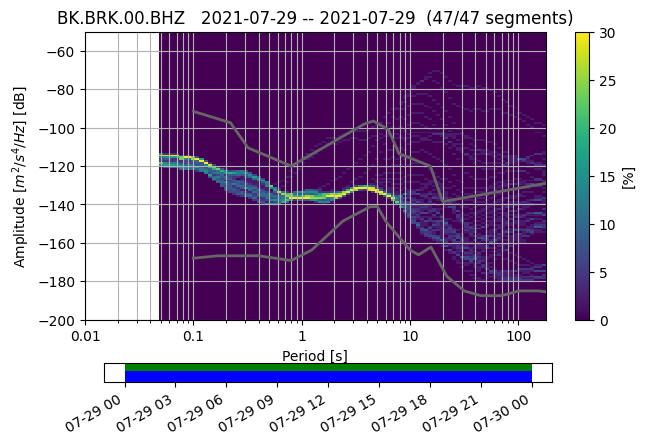

In [179]:
# Plotting PPSD for the urban station
urban_ppsd.plot()

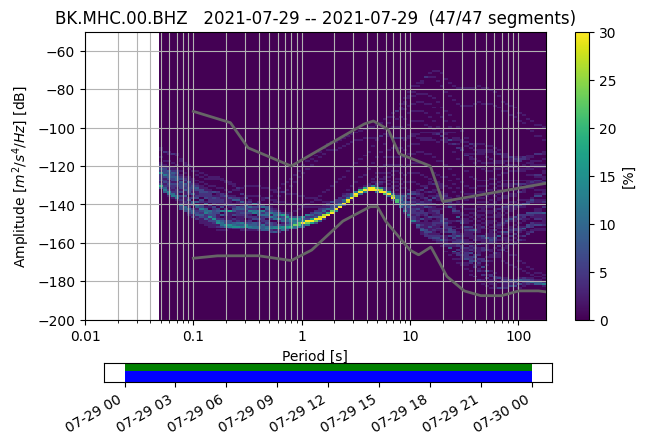

In [180]:
# Plotting PPSD for the rural station
rural_ppsd.plot()

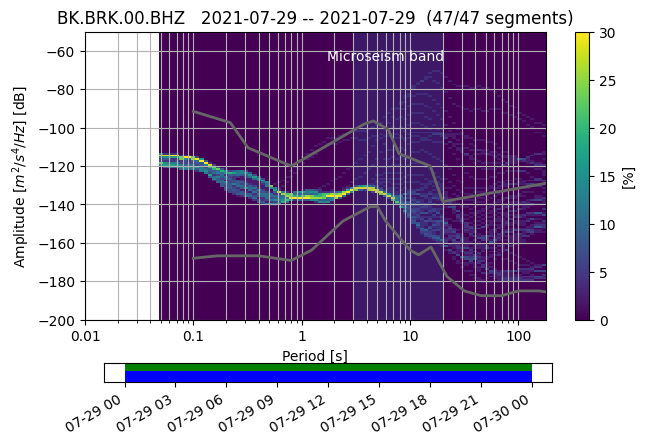

In [181]:
# Urban station PPSD
fig = urban_ppsd.plot(show=False)

ax = fig.axes[0]
ax.axvspan(3, 20, alpha=0.2)
ax.text(
    6, -65,
    "Microseism band",
    ha="center", color="white"
)

plt.show()

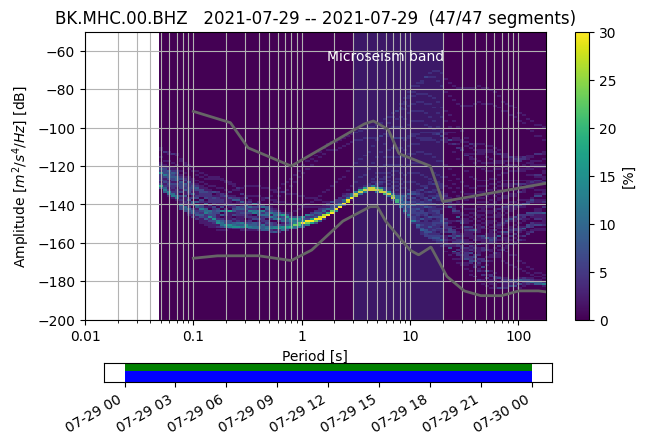

In [182]:
# Rural station PPSD
fig = rural_ppsd.plot(show=False)

ax = fig.axes[0]
ax.axvspan(3, 20, alpha=0.2)
ax.text(
    6, -65,
    "Microseism band",
    ha="center", color="white"
)

plt.show()

BK.MHC generally shows lower noise levels than BK.BRK, particularly at shorter periods. This is consistent with its rural location, where anthropogenic noise from traffic and other human activities is expected to be lower. Both stations show a clear peak within the microseism band, although the peak is sharper and more distinct at BK.MHC. At BK.BRK, the higher background noise at shorter periods makes the microseism peak appear broader and less pronounced.

## Question 3 – Sumatra Earthquakes

### (a) Comparison of Four Large Earthquakes

Four earthquakes with magnitudes of 7.5 or greater in the Sumatra region are selected from the USGS earthquake catalog. Vertical-component velocity records from the same seismic station are used to compare the recorded ground motions.

In [183]:
# Connecting to the USGS earthquake catalog
usgs_client = Client("USGS")

In [184]:
# Searching for M7.5+ earthquakes in the Sumatra region
catalog = usgs_client.get_events(
    starttime=UTCDateTime("2000-01-01"),
    endtime=UTCDateTime("2026-09-19"),
    minmagnitude=7.5,
    minlatitude=-6,
    maxlatitude=7,
    minlongitude=94,
    maxlongitude=106,
    orderby="time-asc"
)

print(catalog)

9 Event(s) in Catalog:
2000-06-04T16:28:26.170000Z |  -4.721, +102.087 | 7.9  mwc | manual
2004-12-26T00:58:53.450000Z |  +3.295,  +95.982 | 9.1  mw | manual
2005-03-28T16:09:36.530000Z |  +2.085,  +97.108 | 8.6  mww | manual
2007-09-12T11:10:26.830000Z |  -4.438, +101.367 | 8.4  mww | manual
2007-09-12T23:49:03.720000Z |  -2.625, +100.841 | 7.9  mwc | manual
2009-09-30T10:16:09.250000Z |  -0.720,  +99.867 | 7.6  mwc | manual
2010-04-06T22:15:01.580000Z |  +2.383,  +97.048 | 7.8  mwc | manual
2010-10-25T14:42:22.460000Z |  -3.487, +100.082 | 7.8  mwc | manual
2016-03-02T12:49:48.110000Z |  -4.952,  +94.330 | 7.8  mww | manual


In [185]:
# Listing the earthquakes
for i, event in enumerate(catalog, 1):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    print(
        f"{i}. "
        f"{origin.time.date} | "
        f"M{magnitude.mag:.1f} | "
        f"Lat: {origin.latitude:.2f}, "
        f"Lon: {origin.longitude:.2f}, "
        f"Depth: {origin.depth / 1000:.1f} km"
    )

1. 2000-06-04 | M7.9 | Lat: -4.72, Lon: 102.09, Depth: 33.0 km
2. 2004-12-26 | M9.1 | Lat: 3.29, Lon: 95.98, Depth: 30.0 km
3. 2005-03-28 | M8.6 | Lat: 2.08, Lon: 97.11, Depth: 30.0 km
4. 2007-09-12 | M8.4 | Lat: -4.44, Lon: 101.37, Depth: 34.0 km
5. 2007-09-12 | M7.9 | Lat: -2.62, Lon: 100.84, Depth: 35.0 km
6. 2009-09-30 | M7.6 | Lat: -0.72, Lon: 99.87, Depth: 81.0 km
7. 2010-04-06 | M7.8 | Lat: 2.38, Lon: 97.05, Depth: 31.0 km
8. 2010-10-25 | M7.8 | Lat: -3.49, Lon: 100.08, Depth: 20.1 km
9. 2016-03-02 | M7.8 | Lat: -4.95, Lon: 94.33, Depth: 24.0 km


In [186]:
# Creating an interactive earthquake map
eq_map = folium.Map(
    location=[0.5, 100.0],
    zoom_start=5,
    tiles="CartoDB positron"
)

# Adding earthquakes
for i, event in enumerate(catalog, 1):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    popup_text = f"""
    <b>Earthquake {i}</b><br>
    Magnitude: {magnitude.mag:.1f}<br>
    Date: {origin.time.date}<br>
    Latitude: {origin.latitude:.2f}<br>
    Longitude: {origin.longitude:.2f}<br>
    Depth: {origin.depth / 1000:.1f} km
    """

    folium.CircleMarker(
        location=[origin.latitude, origin.longitude],
        radius=5 + (magnitude.mag - 7.5) * 10,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{i}: M{magnitude.mag:.1f} - {origin.time.date}",
        fill=True
    ).add_to(eq_map)

eq_map

### Selected Earthquakes

Four earthquakes with magnitudes of 7.5 or greater were selected from the USGS earthquake catalog for the analysis:

- **June 4, 2000 – Mw 7.9**
- **December 26, 2004 – Mw 9.1**
- **March 28, 2005 – Mw 8.6**
- **September 12, 2007 – Mw 8.4**

These earthquakes occurred in the Sumatra region between 2000 and 2007.

In [187]:
# Selected Sumatra earthquakes
selected_events = [
    {
        "date": "2000-06-04",
        "magnitude": 7.9,
        "latitude": -4.72,
        "longitude": 102.09
    },
    {
        "date": "2004-12-26",
        "magnitude": 9.1,
        "latitude": 3.29,
        "longitude": 95.98
    },
    {
        "date": "2005-03-28",
        "magnitude": 8.6,
        "latitude": 2.08,
        "longitude": 97.11
    },
    {
        "date": "2007-09-12",
        "magnitude": 8.4,
        "latitude": -4.44,
        "longitude": 101.37
    }
]

In [188]:
# Getting the selected earthquakes from the USGS catalog
events = [catalog[i] for i in [0, 1, 2, 3]]

for i, event in enumerate(events, 1):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    print(
        f"{i}. {origin.time} | "
        f"M{magnitude.mag:.1f} | "
        f"{origin.latitude:.2f}, {origin.longitude:.2f}"
    )

1. 2000-06-04T16:28:26.170000Z | M7.9 | -4.72, 102.09
2. 2004-12-26T00:58:53.450000Z | M9.1 | 3.29, 95.98
3. 2005-03-28T16:09:36.530000Z | M8.6 | 2.08, 97.11
4. 2007-09-12T11:10:26.830000Z | M8.4 | -4.44, 101.37


In [189]:
# Connecting to EarthScope
earthscope = Client("EARTHSCOPE")

In [190]:
# Finding BHZ stations available for each earthquake
station_sets = []

for event in events:

    origin = event.preferred_origin() or event.origins[0]

    inv = earthscope.get_stations(
        starttime=origin.time,
        endtime=origin.time + 3600,
        minlatitude=-15,
        maxlatitude=20,
        minlongitude=85,
        maxlongitude=120,
        channel="BHZ",
        level="station"
    )

    stations = set()

    for network in inv:
        for station in network:
            stations.add(f"{network.code}.{station.code}")

    station_sets.append(stations)

    print(
        f"{origin.time.date}: "
        f"{len(stations)} BHZ stations"
    )

2000-06-04: 7 BHZ stations
2004-12-26: 7 BHZ stations
2005-03-28: 10 BHZ stations
2007-09-12: 19 BHZ stations


In [191]:
# Finding stations common to all four earthquakes
common_stations = set.intersection(*station_sets)

print("Common stations:")

for station in sorted(common_stations):
    print(station)

Common stations:
GE.UGM
II.COCO
II.KAPI
IU.CHTO
PS.PSI


In [192]:
# Getting information for the common stations
common_inventory = earthscope.get_stations(
    starttime=events[0].preferred_origin().time,
    endtime=events[-1].preferred_origin().time + 3600,
    channel="BHZ",
    level="station"
)

station_info = {}

for network in common_inventory:
    for station in network:

        station_id = f"{network.code}.{station.code}"

        if station_id in common_stations:
            station_info[station_id] = {
                "latitude": station.latitude,
                "longitude": station.longitude,
                "name": station.site.name
            }

            print(
                f"{station_id} | "
                f"{station.latitude:.4f}, {station.longitude:.4f} | "
                f"{station.site.name}"
            )

GE.UGM | -7.9125, 110.5231 | GEOFON Station Wanagama, Indonesia
II.COCO | -12.1901, 96.8349 | West Island, Cocos (Keeling) Islands
II.KAPI | -5.0142, 119.7517 | Kappang, Sulawesi, Indonesia
IU.CHTO | 18.8140, 98.9445 | Chiang Mai, Thailand
PS.PSI | 2.6938, 98.9237 | Parapat, Indonesia


In [193]:
# Creating an interactive map
station_map = folium.Map(
    location=[0, 100],
    zoom_start=4,
    tiles="CartoDB positron"
)

# Adding the earthquakes
for i, event in enumerate(events, 1):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    folium.CircleMarker(
        location=[origin.latitude, origin.longitude],
        radius=8,
        tooltip=f"Earthquake {i}: M{magnitude.mag:.1f}",
        popup=f"M{magnitude.mag:.1f} | {origin.time.date}",
        fill=True
    ).add_to(station_map)

# Adding the common stations
for station_id, info in station_info.items():

    folium.Marker(
        location=[info["latitude"], info["longitude"]],
        tooltip=station_id,
        popup=f"{station_id}<br>{info['name']}"
    ).add_to(station_map)

station_map

In [194]:
# Testing waveform availability for all common stations
test_stations = [
    ("GE", "UGM"),
    ("II", "COCO"),
    ("II", "KAPI"),
    ("IU", "CHTO"),
    ("PS", "PSI")
]

for network, station in test_stations:

    print(f"\n{network}.{station}")

    available = True

    for i, event in enumerate(events, 1):

        origin = event.preferred_origin() or event.origins[0]

        try:
            stream = earthscope.get_waveforms(
                network=network,
                station=station,
                location="*",
                channel="BHZ",
                starttime=origin.time,
                endtime=origin.time + 3600
            )

            print(f"  Earthquake {i}: Available")

        except Exception:
            print(f"  Earthquake {i}: No data")
            available = False

    if available:
        print("  --> Available for all four earthquakes")


GE.UGM
  Earthquake 1: No data
  Earthquake 2: No data
  Earthquake 3: No data
  Earthquake 4: Available

II.COCO
  Earthquake 1: No data
  Earthquake 2: Available
  Earthquake 3: Available
  Earthquake 4: Available

II.KAPI
  Earthquake 1: Available
  Earthquake 2: No data
  Earthquake 3: No data
  Earthquake 4: Available

IU.CHTO
  Earthquake 1: Available
  Earthquake 2: Available
  Earthquake 3: Available
  Earthquake 4: Available
  --> Available for all four earthquakes

PS.PSI
  Earthquake 1: Available
  Earthquake 2: Available
  Earthquake 3: Available
  Earthquake 4: Available
  --> Available for all four earthquakes


### Station Selection

**IU.CHTO – Chiang Mai, Thailand** was selected for the waveform analysis. The station provides BHZ vertical-component data for all four selected earthquakes. The same station and component are used for all four events to allow a consistent comparison of the recorded ground motions.

In [195]:
# Selected seismic station
net = "IU"
sta = "CHTO"
loc = "00"
chan = "BHZ"

In [196]:
# Downloading one hour of BHZ data for each earthquake
waveforms = []

for i, event in enumerate(events, 1):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    stream = earthscope.get_waveforms(
        network=net,
        station=sta,
        location=loc,
        channel=chan,
        starttime=origin.time,
        endtime=origin.time + 3600
    )

    # Merging traces separated by small gaps
    stream.merge(method=1, fill_value="interpolate")

    waveforms.append(stream)

    print(
        f"Earthquake {i}: "
        f"M{magnitude.mag:.1f} | "
        f"{stream}"
    )

Earthquake 1: M7.9 | 1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2000-06-04T16:28:26.173043Z - 2000-06-04T17:28:26.123043Z | 20.0 Hz, 72000 samples
Earthquake 2: M9.1 | 1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2004-12-26T00:58:53.460775Z - 2004-12-26T01:58:53.410775Z | 20.0 Hz, 72000 samples
Earthquake 3: M8.6 | 1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2005-03-28T16:09:36.534768Z - 2005-03-28T17:09:36.484768Z | 20.0 Hz, 72000 samples
Earthquake 4: M8.4 | 1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2007-09-12T11:10:26.847564Z - 2007-09-12T12:10:26.797564Z | 20.0 Hz, 72000 samples


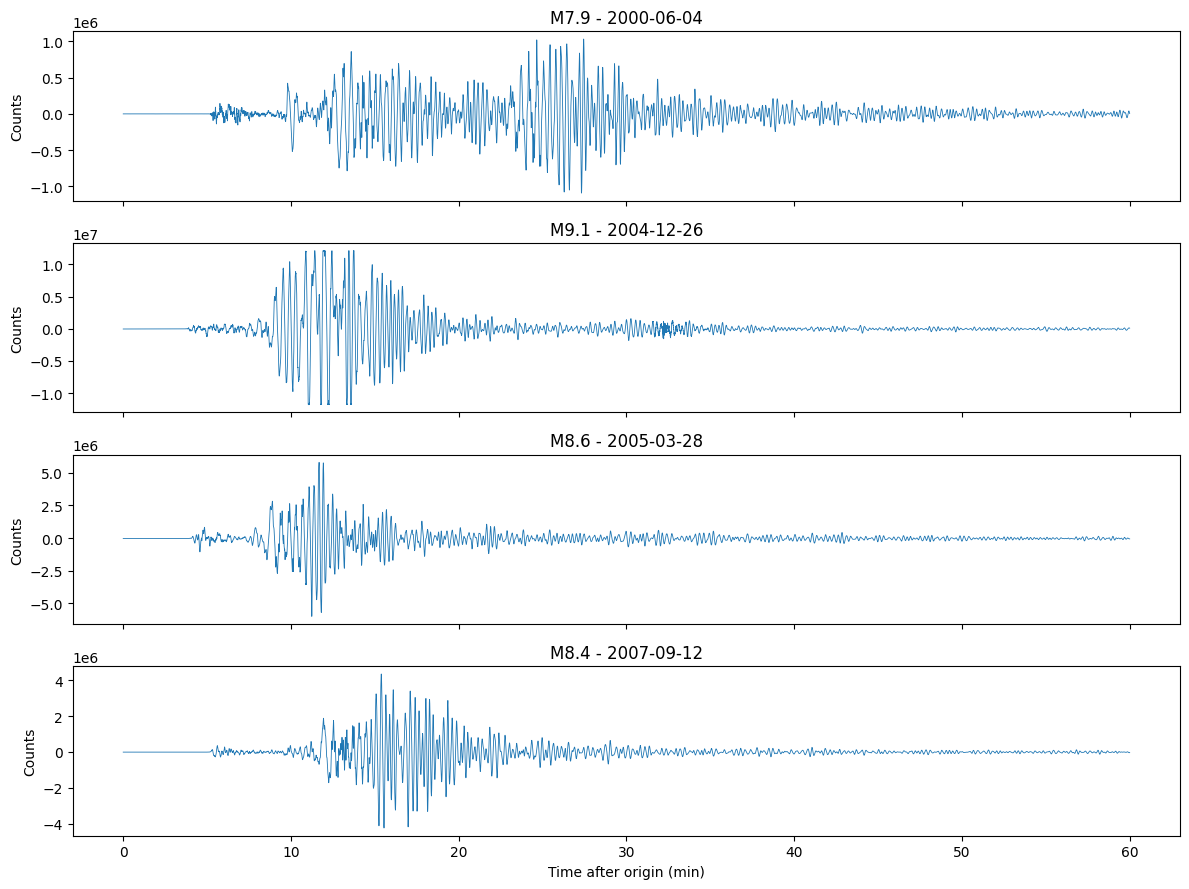

In [197]:
# Plotting the raw waveforms
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

for i, (event, stream) in enumerate(zip(events, waveforms)):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    axes[i].plot(
        stream[0].times() / 60,
        stream[0].data,
        linewidth=0.6
    )

    axes[i].set_title(
        f"M{magnitude.mag:.1f} - {origin.time.date}"
    )
    axes[i].set_ylabel("Counts")

axes[-1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

In [198]:
# Getting instrument response for each earthquake
responses = []

for event in events:

    origin = event.preferred_origin() or event.origins[0]

    inventory = earthscope.get_stations(
        network=net,
        station=sta,
        location=loc,
        channel=chan,
        starttime=origin.time,
        endtime=origin.time + 3600,
        level="response"
    )

    responses.append(inventory)

In [199]:
# Removing the instrument response
velocity_waveforms = []

for stream, inventory in zip(waveforms, responses):

    velocity_stream = stream.copy()

    velocity_stream.detrend("demean")
    velocity_stream.detrend("linear")
    velocity_stream.taper(max_percentage=0.05)

    velocity_stream.remove_response(
        inventory=inventory,
        output="VEL",
        pre_filt=(0.005, 0.01, 8.0, 9.0),
        water_level=60
    )

    velocity_waveforms.append(velocity_stream)

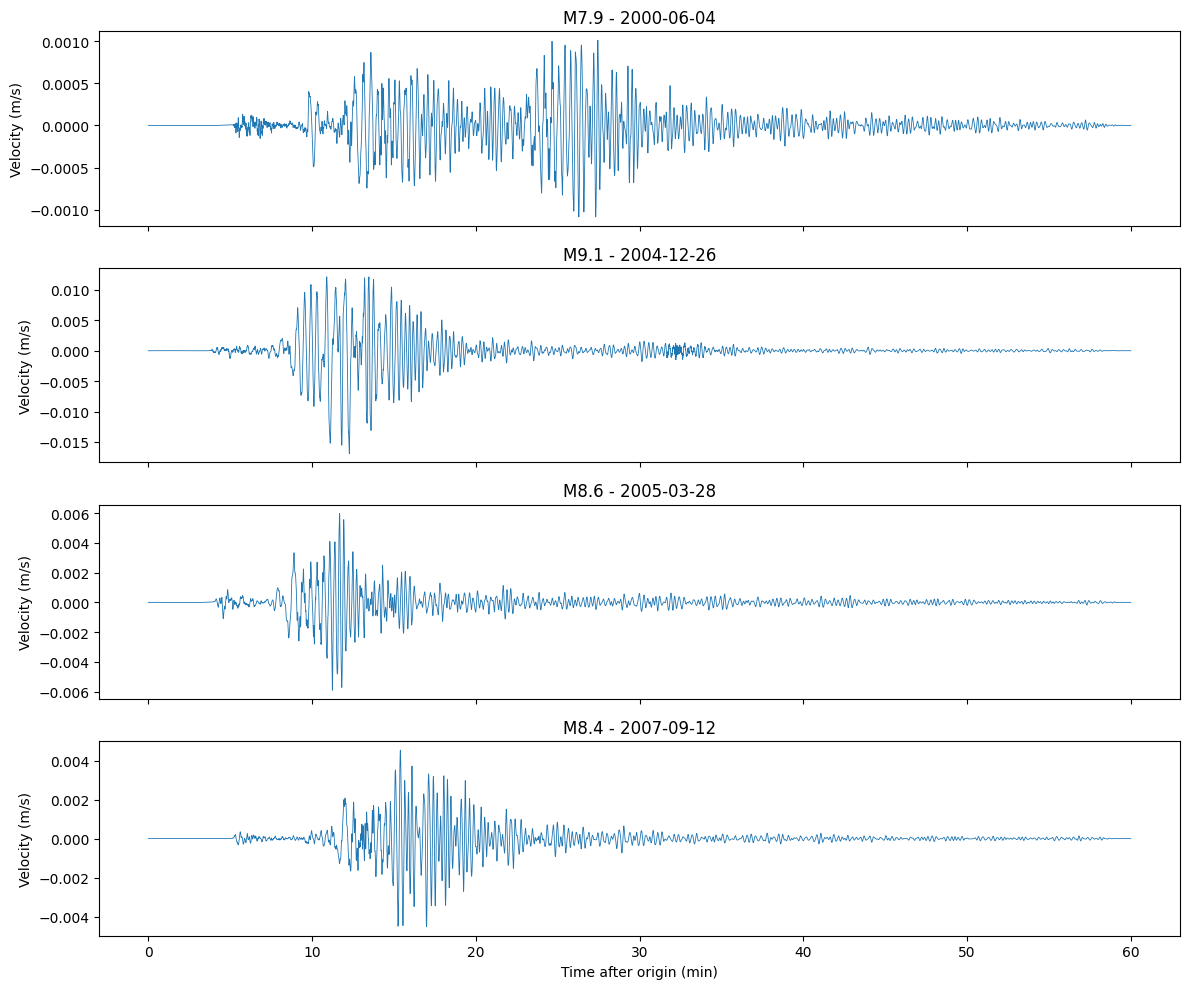

In [200]:
# Plotting the velocity seismograms
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, (event, stream) in enumerate(zip(events, velocity_waveforms)):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    time = stream[0].times() / 60

    axes[i].plot(
        time,
        stream[0].data,
        linewidth=0.6
    )

    axes[i].set_title(
        f"M{magnitude.mag:.1f} - {origin.time.date}"
    )
    axes[i].set_ylabel("Velocity (m/s)")

axes[-1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

The velocity seismograms show differences in both amplitude and duration among the four earthquakes. The M9.1 earthquake produces the largest recorded velocity amplitudes, while the other three events generally show lower amplitudes. The timing and duration of the stronger ground motions also vary between the events. These differences may be related to earthquake magnitude, source characteristics, and differences in the propagation paths to the station.

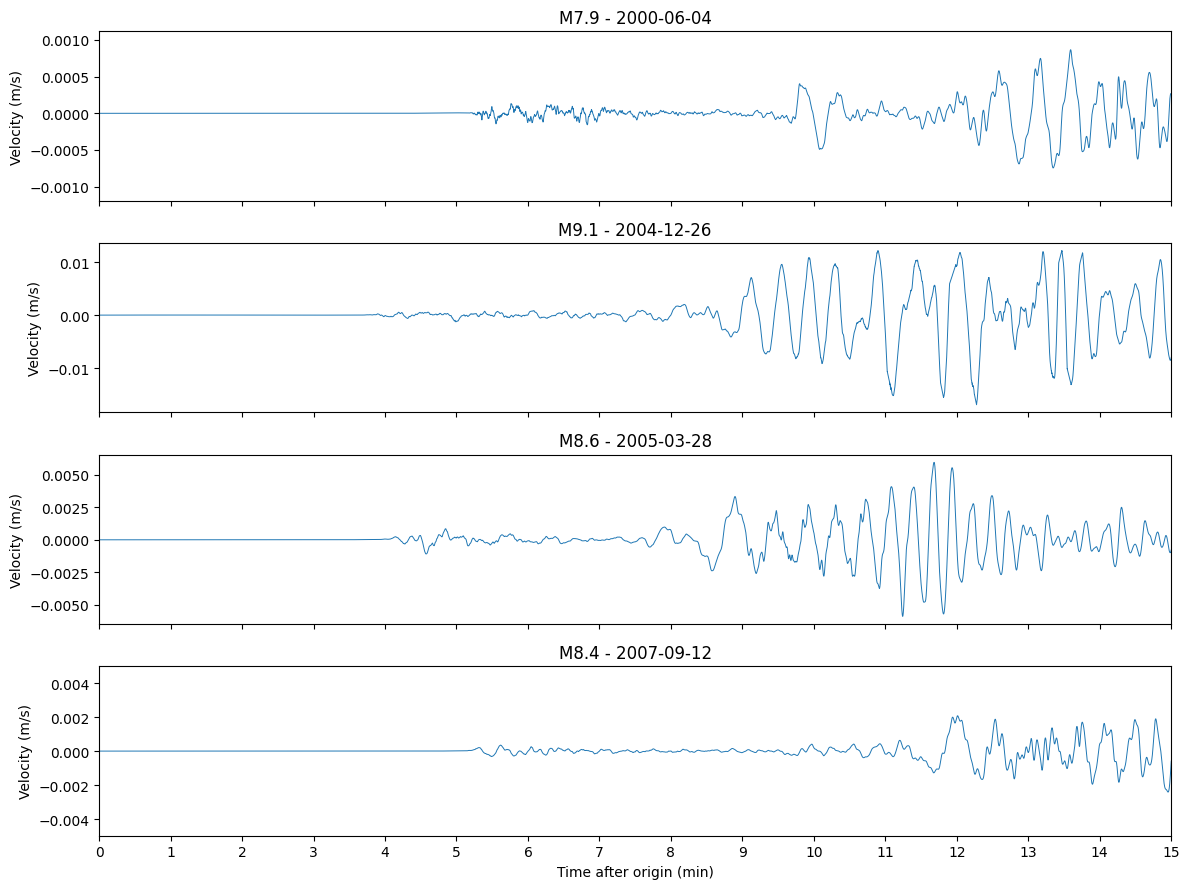

In [201]:
# Zooming in on the first 15 minutes
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

for i, (event, stream) in enumerate(zip(events, velocity_waveforms)):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    time = stream[0].times() / 60

    axes[i].plot(
        time,
        stream[0].data,
        linewidth=0.7
    )

    axes[i].set_xlim(0, 15)
    axes[i].set_xticks(range(0, 16, 1))

    axes[i].set_title(
        f"M{magnitude.mag:.1f} - {origin.time.date}"
    )
    axes[i].set_ylabel("Velocity (m/s)")

axes[-1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

### P-Wave Arrivals and Average P-Wave Velocity

The first 15 minutes of each velocity seismogram are examined to identify the apparent P-wave arrivals. The arrival times are estimated from the first noticeable increase in the recorded ground motion.

The approximate P-wave arrival times are:

- **M7.9 (2000):** 5.2 min
- **M9.1 (2004):** 3.9 min
- **M8.6 (2005):** 4.0 min
- **M8.4 (2007):** 5.2 min

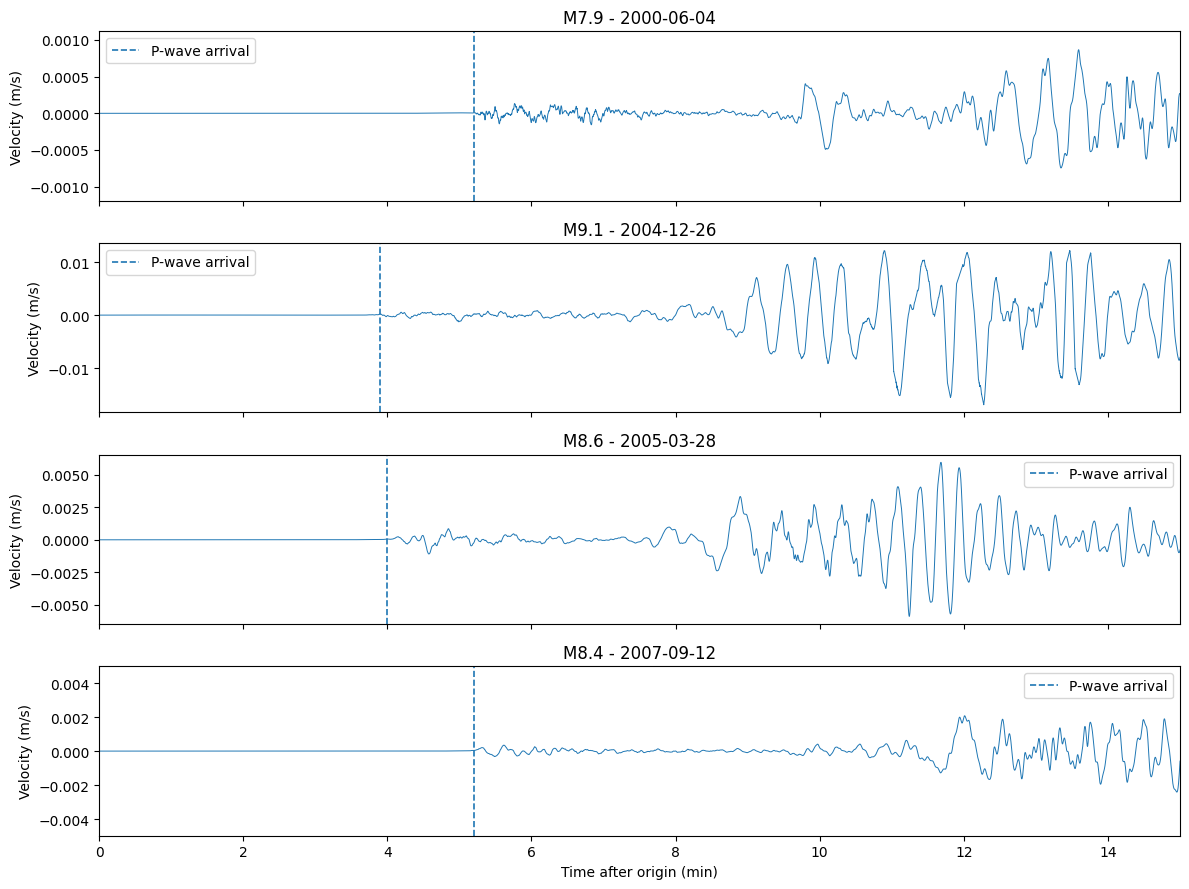

In [202]:
# Estimated P-wave arrivals
p_arrivals = [5.2, 3.9, 4.0, 5.2]

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

for i, (event, stream) in enumerate(zip(events, velocity_waveforms)):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    time = stream[0].times() / 60

    axes[i].plot(
        time,
        stream[0].data,
        linewidth=0.7
    )

    axes[i].axvline(
        p_arrivals[i],
        linestyle="--",
        linewidth=1.2,
        label="P-wave arrival"
    )

    axes[i].set_xlim(0, 15)
    axes[i].set_title(
        f"M{magnitude.mag:.1f} - {origin.time.date}"
    )
    axes[i].set_ylabel("Velocity (m/s)")
    axes[i].legend()

axes[-1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

The epicentral distance between each earthquake and the IU.CHTO station is calculated and divided by the estimated P-wave travel time to obtain an approximate average P-wave velocity.

In [203]:
# Getting station coordinates
station_inventory = earthscope.get_stations(
    network=net,
    station=sta,
    location=loc,
    channel=chan,
    starttime=events[0].preferred_origin().time,
    level="station"
)

station = station_inventory[0][0]

station_lat = station.latitude
station_lon = station.longitude

print(f"IU.CHTO: {station_lat:.4f}, {station_lon:.4f}")

IU.CHTO: 18.8140, 98.9445


In [204]:
from obspy.geodetics import gps2dist_azimuth

# Calculating average P-wave velocities
for i, event in enumerate(events):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    distance_m, _, _ = gps2dist_azimuth(
        origin.latitude,
        origin.longitude,
        station_lat,
        station_lon
    )

    distance_km = distance_m / 1000
    travel_time_s = p_arrivals[i] * 60
    velocity = distance_km / travel_time_s

    print(
        f"M{magnitude.mag:.1f} | "
        f"Distance: {distance_km:.1f} km | "
        f"P arrival: {p_arrivals[i]:.1f} min | "
        f"Average P velocity: {velocity:.2f} km/s"
    )

M7.9 | Distance: 2625.8 km | P arrival: 5.2 min | Average P velocity: 8.42 km/s
M9.1 | Distance: 1746.8 km | P arrival: 3.9 min | Average P velocity: 7.46 km/s
M8.6 | Distance: 1861.3 km | P arrival: 4.0 min | Average P velocity: 7.76 km/s
M8.4 | Distance: 2585.5 km | P arrival: 5.2 min | Average P velocity: 8.29 km/s


In [205]:
# Average P-wave velocity
p_velocities = [8.42, 7.46, 7.76, 8.29]

average_p_velocity = sum(p_velocities) / len(p_velocities)

print(f"Average P-wave velocity: {average_p_velocity:.2f} km/s")

Average P-wave velocity: 7.98 km/s


The estimated average P-wave velocities for the four earthquakes range from approximately 7.5 to 8.4 km/s. The mean value is approximately **8.0 km/s**. The differences between the individual estimates are mainly related to the approximate visual picking of the P-wave arrivals and differences in the source-to-station paths.

### Power Spectral Density

The power spectral densities (PSDs) of the four velocity seismograms are calculated to compare their frequency content. The same station and vertical component are used for all four earthquakes.

In [206]:
from scipy.signal import welch

# Calculating PSDs
psds = []

for stream in velocity_waveforms:

    trace = stream[0]

    frequency, psd = welch(
        trace.data,
        fs=trace.stats.sampling_rate,
        nperseg=4096
    )

    psds.append((frequency, psd))

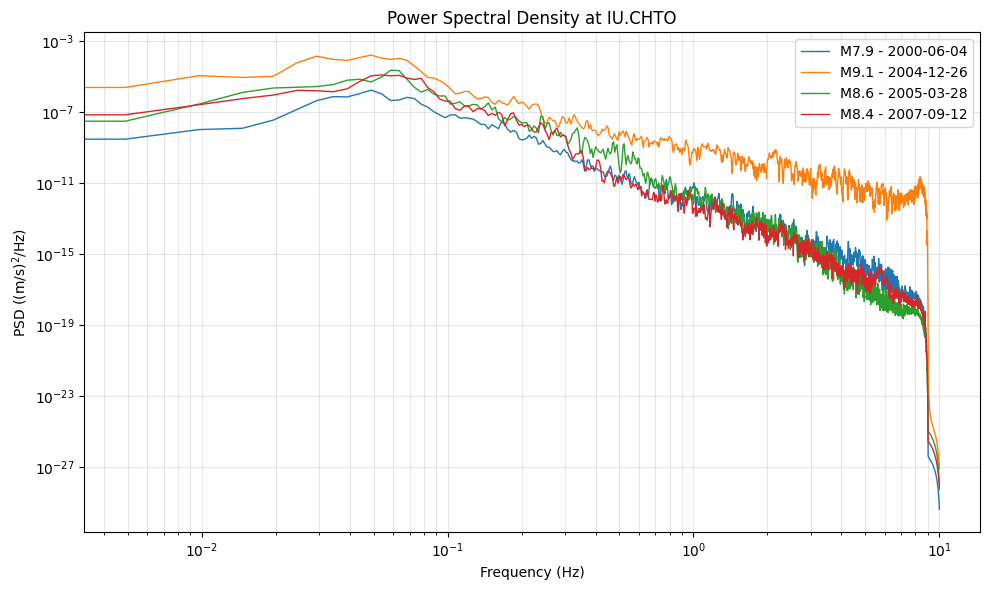

In [207]:
# Plotting the PSDs
plt.figure(figsize=(10, 6))

for event, (frequency, psd) in zip(events, psds):

    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    plt.loglog(
        frequency,
        psd,
        linewidth=1.0,
        label=f"M{magnitude.mag:.1f} - {origin.time.date}"
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD ((m/s)$^2$/Hz)")
plt.title("Power Spectral Density at IU.CHTO")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

The PSDs show clear differences in the frequency content of the four earthquakes. The M9.1 earthquake has the highest spectral power over most of the frequency range. The M8.6 and M8.4 earthquakes show more similar spectral levels, while the M7.9 earthquake generally has lower spectral power. For all four earthquakes, the spectral power generally decreases toward higher frequencies. These differences reflect variations in earthquake magnitude, source characteristics, and source-to-station propagation paths.

### 3b. Comparison of Seismograms at Different Source Distances

The December 26, 2004 M9.1 Sumatra earthquake was selected to compare vertical-component velocity seismograms recorded at four stations at different source distances. The seismograms are plotted as a function of epicentral distance to examine the variation in P-wave arrival time with distance.

In [208]:
# Selecting the 2004 M9.1 Sumatra earthquake
event_3b = events[1]

origin_3b = event_3b.preferred_origin() or event_3b.origins[0]
magnitude_3b = event_3b.preferred_magnitude() or event_3b.magnitudes[0]

print(origin_3b.time)
print(magnitude_3b.mag)

2004-12-26T00:58:53.450000Z
9.1


In [209]:
# Finding stations with BHZ data
stations_3b = earthscope.get_stations(
    channel="BHZ",
    starttime=origin_3b.time,
    endtime=origin_3b.time + 3600,
    latitude=origin_3b.latitude,
    longitude=origin_3b.longitude,
    minradius=5,
    maxradius=60,
    level="station"
)

print(stations_3b)

Inventory created at 2026-09-20T03:34:22.502100Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=200...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (21):
			AU, CB, G, GE, IC, II, IM, IU, JP, KG, KN, KZ, MI, MS, PS, TW, XE, 
			XF, XG, XO, YA
		Stations (440):
			AU.BBOO (Buckleboo, South Australia)
			AU.BLDU (Ballidu, Western Australia)
			AU.COEN (Coen, Queensland)
			AU.FITZ (Fitzroy Crossing)
			AU.FORT (Forrest, WA)
			AU.KMBL (Kambalda, WA)
			AU.MUN (Mundaring, Western Australia)
			AU.NWAO (Narrogin, Western Australia)
			AU.STKA (Stephens Creek, NSW)
			AU.WB0 (Warramunga Array, NT)
			AU.WR0 (Warramunga Array, NT)
			CB.CAD (Changdu, Tibet, China)
			CB.KSH (Kashi,Xingjiang)
			CB.NAQ (Naqu,Tibet,China)
			CB.TNC (Tengchong,Yunnan)
			G.AIS (Nouvelle-Amsterdam - TAAF, France)
			G.ATD (Arta Cave - Arta, Republic of Djibouti)
			G.HYB (Hyderabad, India)
			G.INU

In [210]:
from obspy.geodetics import locations2degrees

# Listing stations by distance
station_list = []

for network in stations_3b:
    for station in network:

        distance = locations2degrees(
            origin_3b.latitude,
            origin_3b.longitude,
            station.latitude,
            station.longitude
        )

        station_list.append(
            (distance, network.code, station.code)
        )

station_list.sort()

for distance, network, station in station_list:
    print(
        f"{network}.{station} | "
        f"Distance: {distance:.1f} degrees"
    )

MS.BTDF | Distance: 8.0 degrees
II.COCO | Distance: 15.5 degrees
II.PALK | Distance: 15.7 degrees
IU.CHTO | Distance: 15.8 degrees
GE.UGM | Distance: 18.3 degrees
IC.QIZ | Distance: 20.8 degrees
YA.MC22 | Distance: 21.6 degrees
CB.TNC | Distance: 21.9 degrees
YA.MC24 | Distance: 21.9 degrees
G.HYB | Distance: 22.2 degrees
YA.MC23 | Distance: 22.3 degrees
YA.MC21 | Distance: 22.5 degrees
IC.KMI | Distance: 22.8 degrees
YA.MC25 | Distance: 22.8 degrees
YA.MC20 | Distance: 22.9 degrees
YA.MC19 | Distance: 23.1 degrees
YA.MC15 | Distance: 23.8 degrees
YA.MC18 | Distance: 23.8 degrees
YA.MC17 | Distance: 23.8 degrees
XF.NBIRA | Distance: 24.6 degrees
YA.MC14 | Distance: 24.8 degrees
YA.MC13 | Distance: 24.9 degrees
YA.MC16 | Distance: 25.0 degrees
YA.MC12 | Distance: 25.1 degrees
XF.NHILE | Distance: 25.2 degrees
II.KAPI | Distance: 25.2 degrees
XF.NJANA | Distance: 25.3 degrees
XF.NTUML | Distance: 25.5 degrees
XF.NRUMJ | Distance: 25.6 degrees
XF.NSIND | Distance: 25.8 degrees
II.DGAR | D

### Station Selection

Four stations at different epicentral distances were selected for the M9.1 earthquake. The selected stations are approximately 16° to 55° from the earthquake source, allowing the change in P-wave arrival time with distance to be compared.

- **IU.CHTO:** 15.8°
- **IU.DAV:** 29.7°
- **IU.INCN:** 44.2°
- **IU.CTAO:** 54.6°

In [211]:
# Downloading BHZ data for the four stations
waveforms_3b = []

for net_3b, sta_3b in selected_stations:

    stream = earthscope.get_waveforms(
        network=net_3b,
        station=sta_3b,
        location="00",
        channel="BHZ",
        starttime=origin_3b.time,
        endtime=origin_3b.time + 3600
    )

    # Merging traces separated by small gaps
    stream.merge(method=1, fill_value="interpolate")

    waveforms_3b.append(stream)

    print(f"{net_3b}.{sta_3b} | {stream}")

IU.CHTO | 1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2004-12-26T00:58:53.460775Z - 2004-12-26T01:58:53.410775Z | 20.0 Hz, 72000 samples
IU.DAV | 1 Trace(s) in Stream:
IU.DAV.00.BHZ | 2004-12-26T00:58:53.460138Z - 2004-12-26T01:58:53.410138Z | 20.0 Hz, 72000 samples
IU.INCN | 1 Trace(s) in Stream:
IU.INCN.00.BHZ | 2004-12-26T00:58:53.473497Z - 2004-12-26T01:58:53.423497Z | 20.0 Hz, 72000 samples
IU.CTAO | 1 Trace(s) in Stream:
IU.CTAO.00.BHZ | 2004-12-26T00:58:53.460645Z - 2004-12-26T01:58:53.410645Z | 20.0 Hz, 72000 samples


### Velocity Seismograms

The instrument response is removed from each waveform to obtain ground velocity in m/s. The same processing is applied to all four stations for a consistent comparison.

In [212]:
# Getting instrument response for each station
responses_3b = []

for net_3b, sta_3b in selected_stations:

    inventory = earthscope.get_stations(
        network=net_3b,
        station=sta_3b,
        location="00",
        channel="BHZ",
        starttime=origin_3b.time,
        endtime=origin_3b.time + 3600,
        level="response"
    )

    responses_3b.append(inventory)

In [213]:
# Removing the instrument response
velocity_waveforms_3b = []

for stream, inventory in zip(waveforms_3b, responses_3b):

    velocity_stream = stream.copy()

    velocity_stream.detrend("demean")
    velocity_stream.detrend("linear")
    velocity_stream.taper(max_percentage=0.05)

    velocity_stream.remove_response(
        inventory=inventory,
        output="VEL",
        pre_filt=(0.005, 0.01, 8.0, 9.0),
        water_level=60
    )

    velocity_waveforms_3b.append(velocity_stream)

In [214]:
# Epicentral distances in degrees
distances_3b = [15.8, 29.7, 44.2, 54.6]

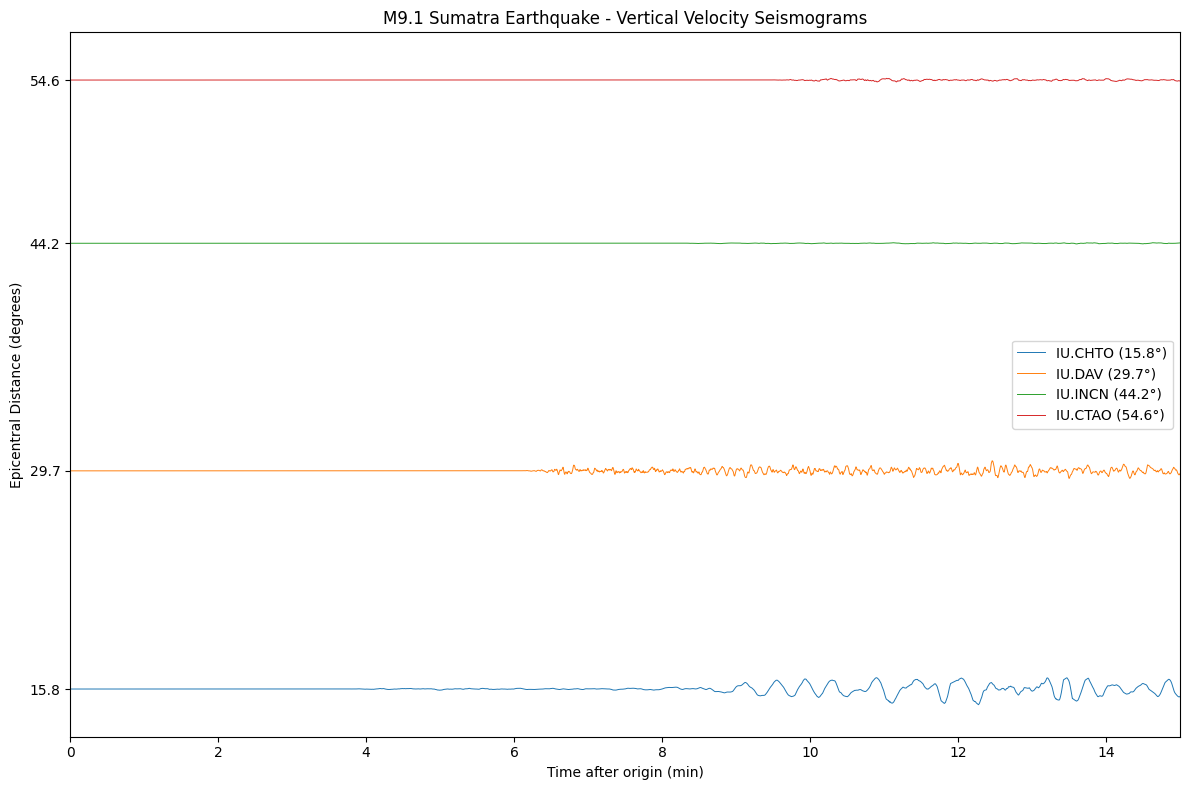

In [215]:
# Plotting seismograms as a function of distance
plt.figure(figsize=(12, 8))

for (net_3b, sta_3b), stream, distance in zip(
    selected_stations, velocity_waveforms_3b, distances_3b
):

    trace = stream[0]
    time = trace.times() / 60

    normalized_data = trace.data / max(abs(trace.data))

    plt.plot(
        time,
        normalized_data + distance,
        linewidth=0.7,
        label=f"{net_3b}.{sta_3b} ({distance:.1f}°)"
    )

plt.xlabel("Time after origin (min)")
plt.ylabel("Epicentral Distance (degrees)")
plt.title("M9.1 Sumatra Earthquake - Vertical Velocity Seismograms")
plt.xlim(0, 15)
plt.yticks(distances_3b)
plt.legend()

plt.tight_layout()
plt.show()

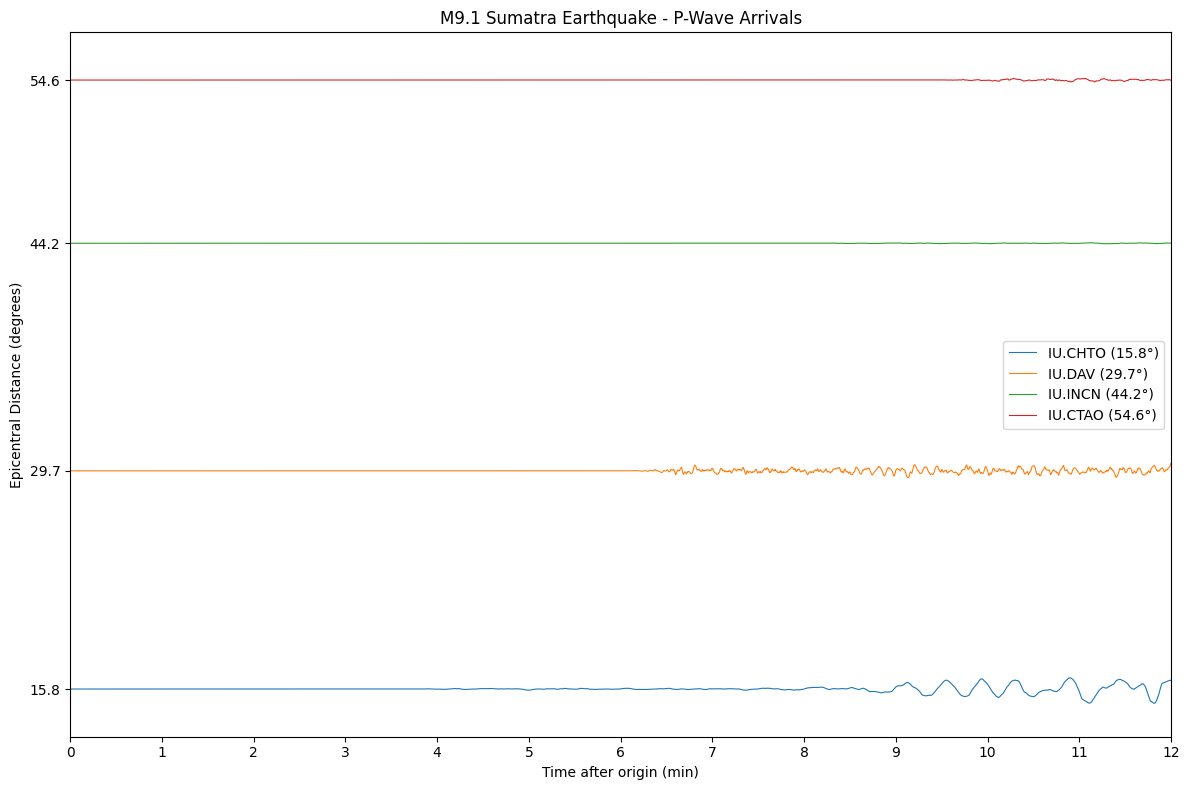

In [216]:
# Zooming in on the P-wave arrivals
plt.figure(figsize=(12, 8))

for (net_3b, sta_3b), stream, distance in zip(
    selected_stations, velocity_waveforms_3b, distances_3b
):

    trace = stream[0]
    time = trace.times() / 60

    normalized_data = trace.data / max(abs(trace.data))

    plt.plot(
        time,
        normalized_data + distance,
        linewidth=0.8,
        label=f"{net_3b}.{sta_3b} ({distance:.1f}°)"
    )

plt.xlabel("Time after origin (min)")
plt.ylabel("Epicentral Distance (degrees)")
plt.title("M9.1 Sumatra Earthquake - P-Wave Arrivals")

plt.xlim(0, 12)
plt.xticks(range(0, 13, 1))
plt.yticks(distances_3b)

plt.legend()
plt.tight_layout()
plt.show()

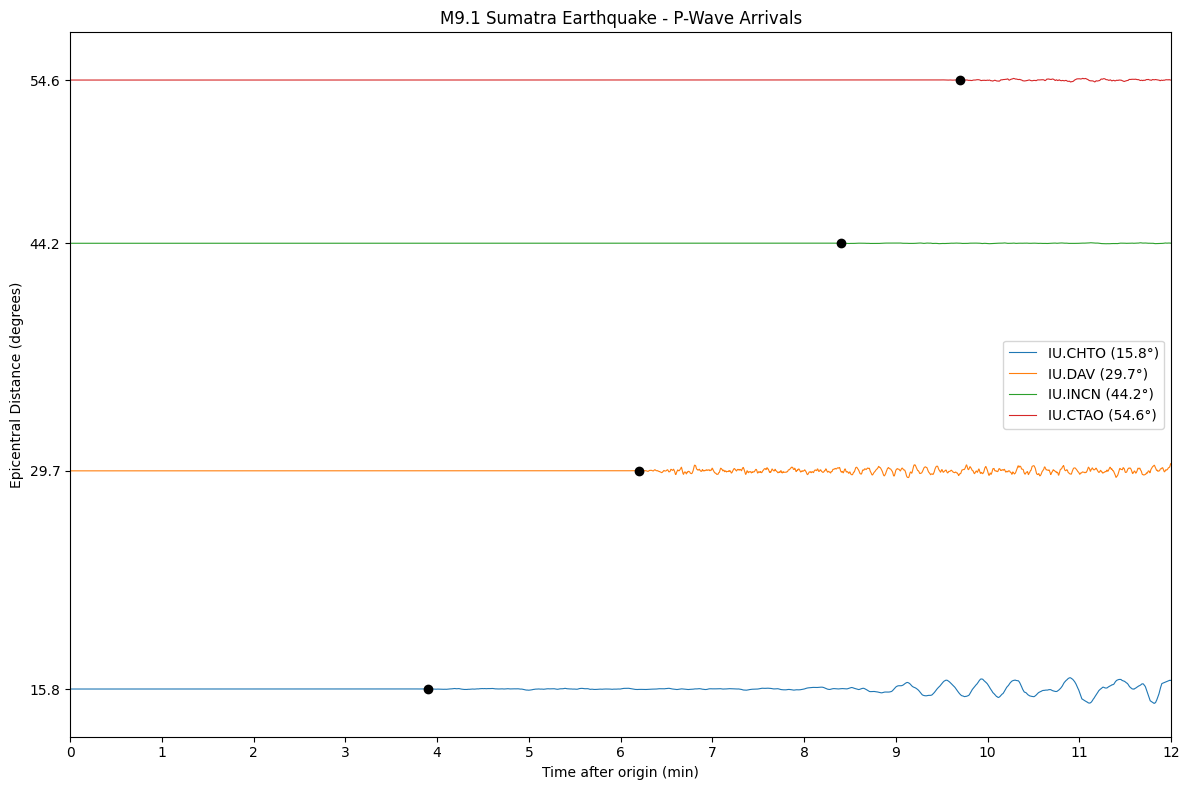

In [217]:
# Estimated P-wave arrivals
p_arrivals_3b = [3.9, 6.2, 8.4, 9.7]

plt.figure(figsize=(12, 8))

for (net_3b, sta_3b), stream, distance, p_arrival in zip(
    selected_stations,
    velocity_waveforms_3b,
    distances_3b,
    p_arrivals_3b
):

    trace = stream[0]
    time = trace.times() / 60
    normalized_data = trace.data / max(abs(trace.data))

    plt.plot(
        time,
        normalized_data + distance,
        linewidth=0.8,
        label=f"{net_3b}.{sta_3b} ({distance:.1f}°)"
    )

    plt.plot(
        p_arrival,
        distance,
        "ko"
    )

plt.xlabel("Time after origin (min)")
plt.ylabel("Epicentral Distance (degrees)")
plt.title("M9.1 Sumatra Earthquake - P-Wave Arrivals")

plt.xlim(0, 12)
plt.xticks(range(0, 13, 1))
plt.yticks(distances_3b)
plt.legend()

plt.tight_layout()
plt.show()

### P-Wave Arrivals

The P-wave arrival at each station was estimated from the first noticeable change in the velocity seismogram. As expected, the P-wave arrives later as the epicentral distance increases.

The approximate P-wave arrival times are:

- **IU.CHTO (15.8°):** 3.9 min
- **IU.DAV (29.7°):** 6.2 min
- **IU.INCN (44.2°):** 8.4 min
- **IU.CTAO (54.6°):** 9.7 min

### Average P-Wave Velocity

The epicentral distances are converted from degrees to kilometers and divided by the estimated P-wave travel times. This provides an approximate average P-wave velocity for each source-to-station path.

In [218]:
# Calculating average P-wave velocities
p_velocities_3b = []

for (net_3b, sta_3b), distance_deg, p_arrival in zip(
    selected_stations,
    distances_3b,
    p_arrivals_3b
):

    distance_km = distance_deg * 111.2
    travel_time_s = p_arrival * 60

    velocity = distance_km / travel_time_s
    p_velocities_3b.append(velocity)

    print(
        f"{net_3b}.{sta_3b} | "
        f"Distance: {distance_deg:.1f}° | "
        f"P arrival: {p_arrival:.1f} min | "
        f"Average P velocity: {velocity:.2f} km/s"
    )

average_p_velocity_3b = sum(p_velocities_3b) / len(p_velocities_3b)

print(f"\nAverage P-wave velocity: {average_p_velocity_3b:.2f} km/s")

IU.CHTO | Distance: 15.8° | P arrival: 3.9 min | Average P velocity: 7.51 km/s
IU.DAV | Distance: 29.7° | P arrival: 6.2 min | Average P velocity: 8.88 km/s
IU.INCN | Distance: 44.2° | P arrival: 8.4 min | Average P velocity: 9.75 km/s
IU.CTAO | Distance: 54.6° | P arrival: 9.7 min | Average P velocity: 10.43 km/s

Average P-wave velocity: 9.14 km/s


In [219]:
p_arrivals_3b = [3.9, 6.2, 8.4, 9.7]
distances_3b = [15.8, 29.7, 44.2, 54.6]

In [220]:
# Estimating average P-wave velocity
distance_km = np.array(distances_3b) * 111.2
arrival_time_s = np.array(p_arrivals_3b) * 60

slope, intercept = np.polyfit(arrival_time_s, distance_km, 1)

print(f"Estimated average P-wave velocity: {slope:.2f} km/s")

Estimated average P-wave velocity: 12.30 km/s


The estimated P-wave velocities range from approximately 7.5 to 10.4 km/s for the four stations, with an average value of approximately **9.1 km/s**. The P-wave arrival occurs later as the source-to-station distance increases. A linear fit between epicentral distance and P-wave arrival time gives an apparent velocity of approximately **12.3 km/s**. The higher value from the linear fit reflects the non-linear P-wave travel-time relationship as the waves travel through deeper and faster regions of the Earth. Therefore, these values should be considered approximate estimates based on the observed P-wave arrivals.

### 3c. High-Pass Filtering and Phase Arrivals

The vertical-component velocity seismogram recorded at IU.CHTO for the December 26, 2004 M9.1 Sumatra earthquake was selected. High-pass filters with corner frequencies of 0.01 Hz and 1 Hz are applied to compare how the frequency content of the waveform changes.

In [221]:
# Selecting the IU.CHTO velocity waveform
waveform_3c = velocity_waveforms_3b[0].copy()

# Creating copies for filtering
waveform_001 = waveform_3c.copy()
waveform_1 = waveform_3c.copy()

# Applying high-pass filters
waveform_001.filter(
    "highpass",
    freq=0.01,
    corners=4,
    zerophase=True
)

waveform_1.filter(
    "highpass",
    freq=1.0,
    corners=4,
    zerophase=True
)

1 Trace(s) in Stream:
IU.CHTO.00.BHZ | 2004-12-26T00:58:53.460775Z - 2004-12-26T01:58:53.410775Z | 20.0 Hz, 72000 samples

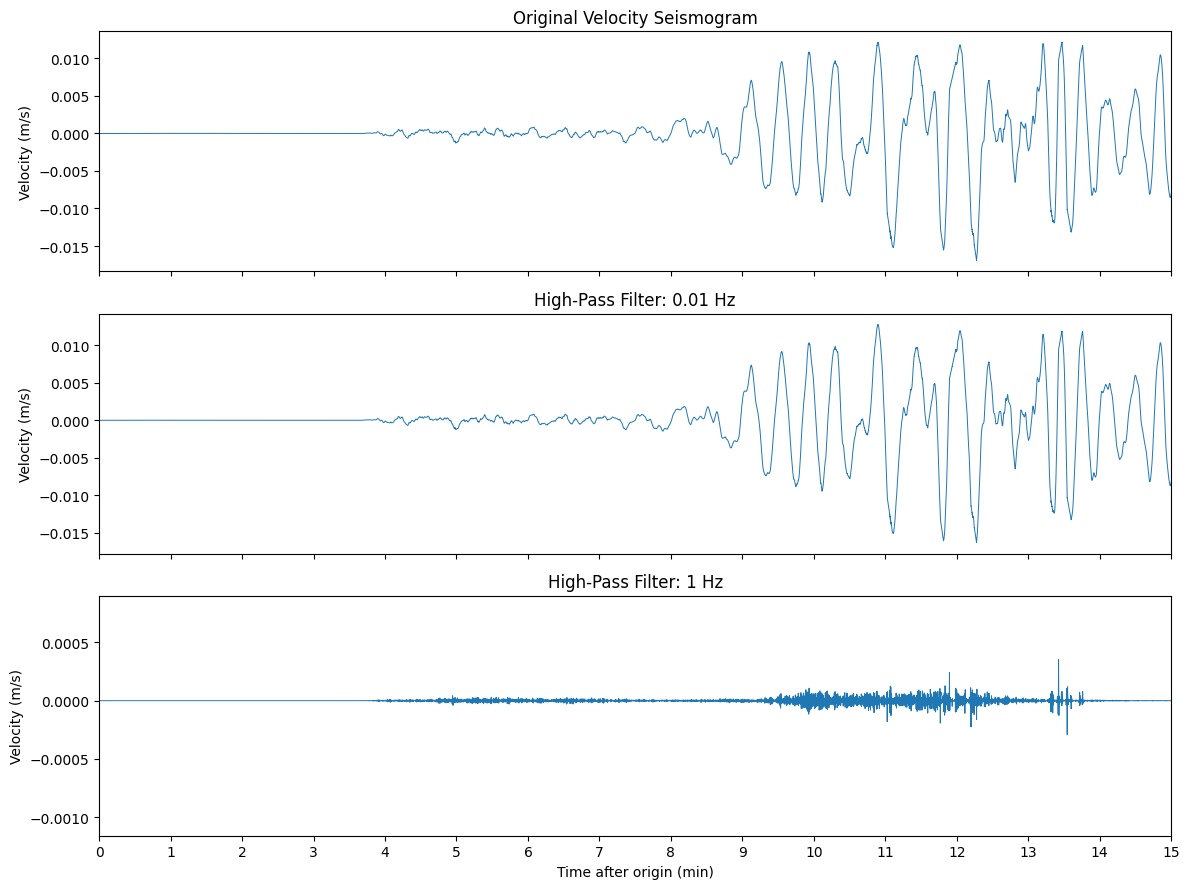

In [222]:
# Plotting the original and filtered waveforms
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

time = waveform_3c[0].times() / 60

axes[0].plot(
    time,
    waveform_3c[0].data,
    linewidth=0.7
)
axes[0].set_title("Original Velocity Seismogram")

axes[1].plot(
    time,
    waveform_001[0].data,
    linewidth=0.7
)
axes[1].set_title("High-Pass Filter: 0.01 Hz")

axes[2].plot(
    time,
    waveform_1[0].data,
    linewidth=0.7
)
axes[2].set_title("High-Pass Filter: 1 Hz")

for ax in axes:
    ax.set_ylabel("Velocity (m/s)")
    ax.set_xlim(0, 15)
    ax.set_xticks(range(0, 16, 1))

axes[-1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

### Phase Arrivals

Theoretical seismic phase arrival times are calculated and compared with the filtered seismograms. This helps identify the phases visible in the recorded waveform.

In [223]:
# Calculating P- and S-wave arrival times
phase_arrivals = model.get_travel_times(
    source_depth_in_km=origin_3b.depth / 1000,
    distance_in_degree=15.8,
    phase_list=["P", "S"]
)

for arrival in phase_arrivals:
    print(f"{arrival.name}: {arrival.time / 60:.2f} min")

P: 3.67 min
P: 3.68 min
P: 3.68 min
P: 3.73 min
P: 3.73 min
S: 6.59 min
S: 6.81 min
S: 6.82 min


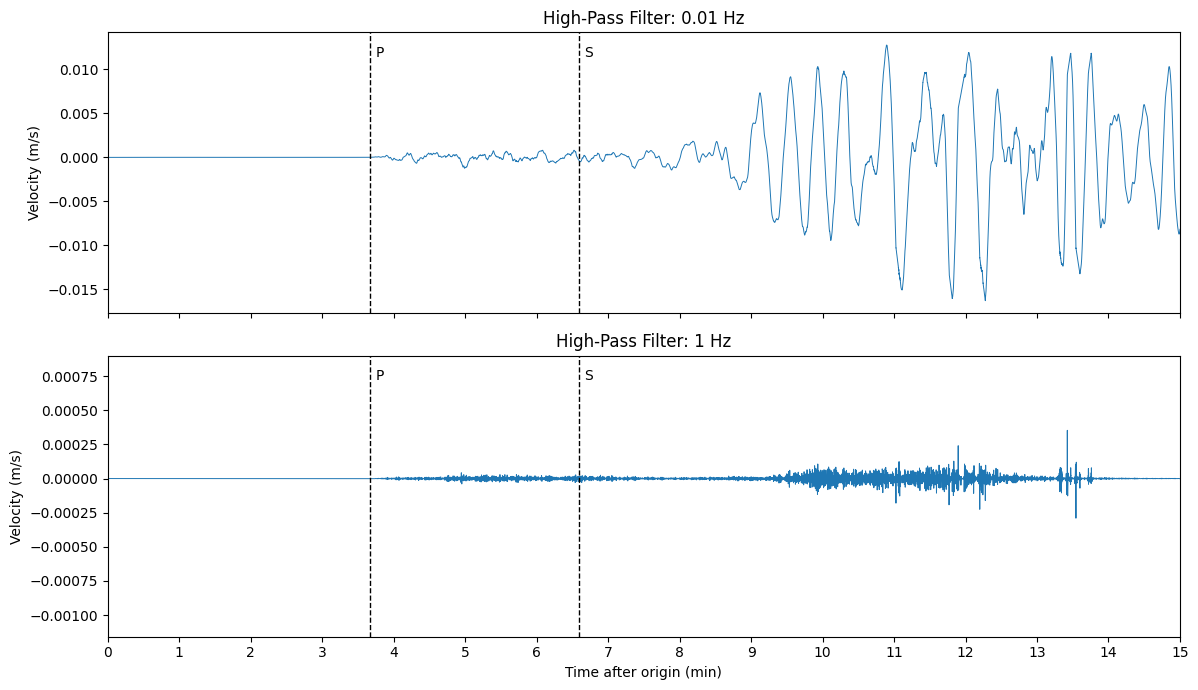

In [224]:
# Phase arrival times
p_time = 3.67
s_time = 6.59

# Plotting the filtered waveforms
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

time = waveform_3c[0].times() / 60

axes[0].plot(time, waveform_001[0].data, linewidth=0.7)
axes[0].set_title("High-Pass Filter: 0.01 Hz")

axes[1].plot(time, waveform_1[0].data, linewidth=0.7)
axes[1].set_title("High-Pass Filter: 1 Hz")

for ax in axes:
    ax.axvline(p_time, color="black", linestyle="--", linewidth=1)
    ax.axvline(s_time, color="black", linestyle="--", linewidth=1)

    ax.text(p_time + 0.08, ax.get_ylim()[1] * 0.8, "P")
    ax.text(s_time + 0.08, ax.get_ylim()[1] * 0.8, "S")

    ax.set_ylabel("Velocity (m/s)")
    ax.set_xlim(0, 15)
    ax.set_xticks(range(0, 16, 1))

axes[1].set_xlabel("Time after origin (min)")

plt.tight_layout()
plt.show()

### High-Pass Filtering

The vertical-component velocity seismogram recorded at IU.CHTO for the December 26, 2004 M9.1 Sumatra earthquake was high-pass filtered at 0.01 Hz and 1 Hz. The 0.01 Hz filtered waveform retains most of the long-period ground motion, while the 1 Hz filter removes the long-period components and emphasizes the higher-frequency motion.

The theoretical P- and S-wave arrival times are approximately **3.67 min** and **6.59 min**, respectively, and are shown on the filtered seismograms.